# HuggingFace Trainer Pipeline

Base model: MARBERTv2

**Setup**

In [1]:
import os
from google.colab import userdata
!git config --global user.name "sivrox"
repo_url = "https://github.com/sivrox/Arabic-English-Sentiment-Analysis-Project.git"

if not os.path.exists("/content/Arabic-English-Sentiment-Analysis-Project"):
    os.system(f"git clone {repo_url}")
else:
    os.system("cd /content/Arabic-English-Sentiment-Analysis-Project && git pull")

%cd /content/Arabic-English-Sentiment-Analysis-Project
print("Repository cloned.")
!ls

/content/Arabic-English-Sentiment-Analysis-Project
Repository cloned.
configs     models		    preprocessing  results_comparison.csv
deployment  notebooks		    README.md	   session.tw_session
evaluation  peft_implementation.py  results


In [5]:
#install required packages
!pip install -q transformers==4.41.0 peft==0.10.0 accelerate==0.28.0 scikit-learn evaluate seaborn matplotlib nltk pyarrow pandas datasets emoji

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 122.8 MB/s eta 0:00:00


In [6]:
import os, sys, random, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import evaluate
import nltk
nltk.download("punkt", quiet=True)

# fix random seed for reproducibility — must match Notebook 01 for a fair comparison
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

#add repo root to path so we can import our preprocessing module
sys.path.insert(0, "/content/Arabic-English-Sentiment-Analysis-Project")

#hyperparameters
model_name = "UBC-NLP/MARBERTv2"
max_len = 128
batch_size = 16
epochs = 3
lr_full = 2e-5
lr_lora = 3e-4
num_labels = 3
patience = 3

#label encoding
id2label = {0: "negative", 1: "neutral", 2: "positive"}
label2id = {"negative": 0, "neutral": 1, "positive": 2}

#output folder for plots and CSVs
Path("results/huggingface").mkdir(parents=True, exist_ok=True)
print("Config ready.")

Device: cuda
GPU  : NVIDIA A100-SXM4-40GB
VRAM : 42.4 GB
Config ready.


**Load Data**

In [7]:
from preprocessing.preprocessor import build_hf_datasets

data_path = "preprocessing/datasets/processed/unified_raw.csv"  #build_hf_datasets runs the same cleaning pipeline as build_dataloaders in pytorch pipeline but returns HuggingFace Dataset objects instead of PyTorch DataLoaders

print("Building HuggingFace datasets for MARBERT...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
train_ds, val_ds, test_ds = build_hf_datasets(data_path, tokenizer, max_length=max_len, seed=seed, save_cleaned_csv=False)
print(f"\nDatasets ready — Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")

Building HuggingFace datasets for MARBERT...


tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Starting preprocessing pipeline (HuggingFace Trainer format)...
Tokenizer: UBC-NLP/MARBERTv2
Loaded: 306,880 rows

Cleaning text...
Rows after filtering: 301,588  (removed 5,292)
Training set balanced: 151,242 samples

Tokenizing datasets...


Map:   0%|          | 0/151242 [00:00<?, ? examples/s]

Map:   0%|          | 0/29629 [00:00<?, ? examples/s]

Map:   0%|          | 0/32340 [00:00<?, ? examples/s]


Done. Train: 151,242 | Val: 29,629 | Test: 32,340

Datasets ready — Train: 151,242 | Val: 29,629 | Test: 32,340


**Helper Functions**

In [11]:
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred): #called automatically by the Trainer after each evaluation epoch
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    acc = accuracy_score(labels, preds)
    return {"macro_f1": macro_f1, "accuracy": acc}

def plot_trainer_history(trainer, title, save_path):  #extract training log from the Trainer's internal state object
    log = trainer.state.log_history
    train_loss = [e["loss"] for e in log if "loss" in e and "eval_loss" not in e]
    val_loss = [e["eval_loss"] for e in log if "eval_loss" in e]
    val_f1 = [e["eval_macro_f1"] for e in log if "eval_macro_f1" in e]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    if train_loss: ax1.plot(train_loss, label="Train")
    if val_loss: ax1.plot(val_loss, label="Val")
    ax1.set(title=f"{title} — Loss", xlabel="Step", ylabel="Loss")
    ax1.legend()
    if val_f1: ax2.plot(val_f1, label="Val Macro F1", color="green")
    ax2.set(title=f"{title} — Macro F1", xlabel="Eval Step", ylabel="F1")
    ax2.legend()
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

def plot_confusion_matrix(preds, labels, title, save_path): #shows per-class prediction breakdown
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Neutral", "Positive"],
                yticklabels=["Negative", "Neutral", "Positive"])
    plt.title(f"{title} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

def print_report(preds, labels, title): #per-class precision, recall, F1 from sklearn
    print(f"\n{title} — Classification Report")
    print(classification_report(labels, preds, target_names=["Negative", "Neutral", "Positive"]))

def full_evaluation(trainer, dataset, title, cm_save_path):
    preds_out = trainer.predict(dataset)
    preds = np.argmax(preds_out.predictions, axis=-1)
    labels = preds_out.label_ids
    macro_f1 = f1_score(labels, preds, average="macro")
    acc = accuracy_score(labels, preds)
    print(f"\n{title} — Test Macro F1: {macro_f1:.4f}  |  Accuracy: {acc:.4f}")
    print_report(preds, labels, title)
    plot_confusion_matrix(preds, labels, title, cm_save_path)
    return macro_f1, acc, preds, labels

def make_args(output_dir, lr):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.1,
        evaluation_strategy="epoch",       # evaluate on val set after every epoch
        save_strategy="epoch",             # save checkpoint after every epoch
        load_best_model_at_end=True,       # automatically restore best checkpoint when training ends
        metric_for_best_model="macro_f1",  # use macro F1 to decide which checkpoint is best
        greater_is_better=True,
        logging_steps=100,
        seed=seed,
        fp16=torch.cuda.is_available(),    # mixed precision for faster A100 training
        report_to="none",                  # disable wandb/tensorboard logging
    )

Strategy A - **Full Fine-Tuning**

In [18]:
#load pretrained MARBERT with a fresh 3-class classification head
print("Loading MARBERT for Full Fine-Tuning...")
model_fft = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)
trainable = sum(p.numel() for p in model_fft.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_fft.parameters())
print(f"\nTrainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

trainer_fft = Trainer(
    model=model_fft,
    args=make_args("hf_outputs/marbert_fft", lr_full),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)],
)
print("\nTraining MARBERT Full Fine-Tuning...")
trainer_fft.train()

Loading MARBERT for Full Fine-Tuning...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERTv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Trainable parameters: 162,843,651 / 162,843,651 (100.0%)

Training MARBERT Full Fine-Tuning...


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.305800,0.287168,0.878920,0.896588
2,0.211500,0.305338,0.885277,0.902224
3,0.160000,0.373604,0.891570,0.909413


TrainOutput(global_step=28359, training_loss=0.26830615781754935, metrics={'train_runtime': 1654.8955, 'train_samples_per_second': 274.172, 'train_steps_per_second': 17.136, 'total_flos': 2.984534964301363e+16, 'train_loss': 0.26830615781754935, 'epoch': 3.0})

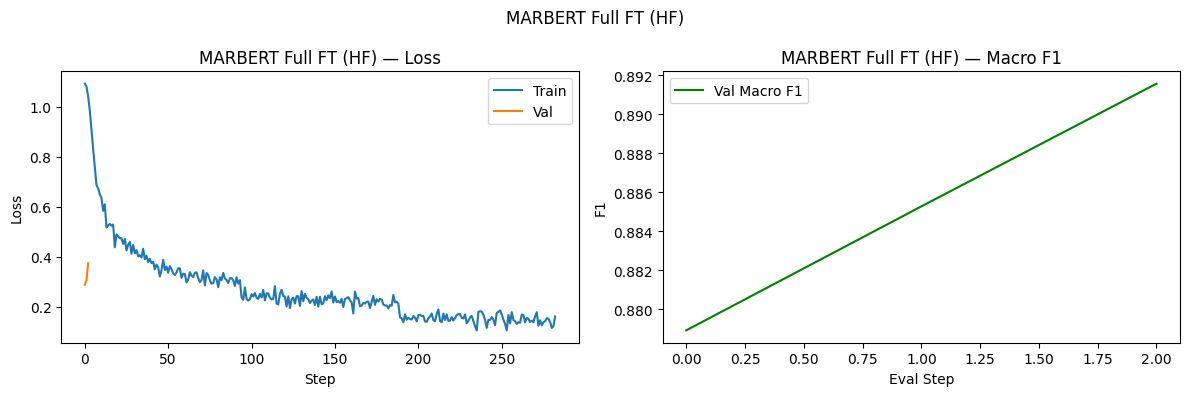


MARBERT Full FT (HF) — Test Macro F1: 0.8828  |  Accuracy: 0.8998

MARBERT Full FT (HF) — Classification Report
              precision    recall  f1-score   support

    Negative       0.83      0.88      0.85      5923
     Neutral       0.97      0.90      0.94     18036
    Positive       0.82      0.91      0.86      8381

    accuracy                           0.90     32340
   macro avg       0.87      0.90      0.88     32340
weighted avg       0.91      0.90      0.90     32340



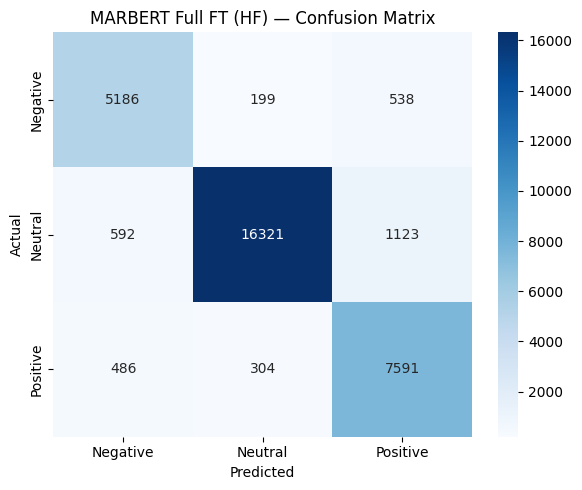

In [19]:
#plot training curves
plot_trainer_history(trainer_fft, "MARBERT Full FT (HF)", "results/huggingface/marbert_fft_curves.png")
f1_fft, acc_fft, preds_fft, labels_test = full_evaluation(trainer_fft, test_ds, "MARBERT Full FT (HF)", "results/huggingface/marbert_fft_cm.png")

Strategy B - **LoRA (peft library)**

In [14]:
#PEFT is carried out by HuggingFace peft library LoraConfig unlike the pytorch pipeline which uses the from-scratch implementation in peft_implementation.py
print("Loading MARBERT for LoRA...")
lora_base = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],  #same layers targeted by peft_implementation.py
    bias="none",
)
model_lora = get_peft_model(lora_base, lora_config)

#confirms expected reduction: ~1M trainable out of 163M total parameters
model_lora.print_trainable_parameters()

trainer_lora = Trainer(
    model=model_lora,
    args=make_args("hf_outputs/marbert_lora", lr_lora),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)],
)
print("\nTraining MARBERT LoRA...")
trainer_lora.train()
print("Done.")

Loading MARBERT for LoRA...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERTv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 297,219 || all params: 163,140,870 || trainable%: 0.1821854940457287

Training MARBERT LoRA...


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.383600,0.343073,0.846274,0.867596
2,0.315200,0.314606,0.861578,0.881265
3,0.315600,0.313508,0.863798,0.881332


Done.


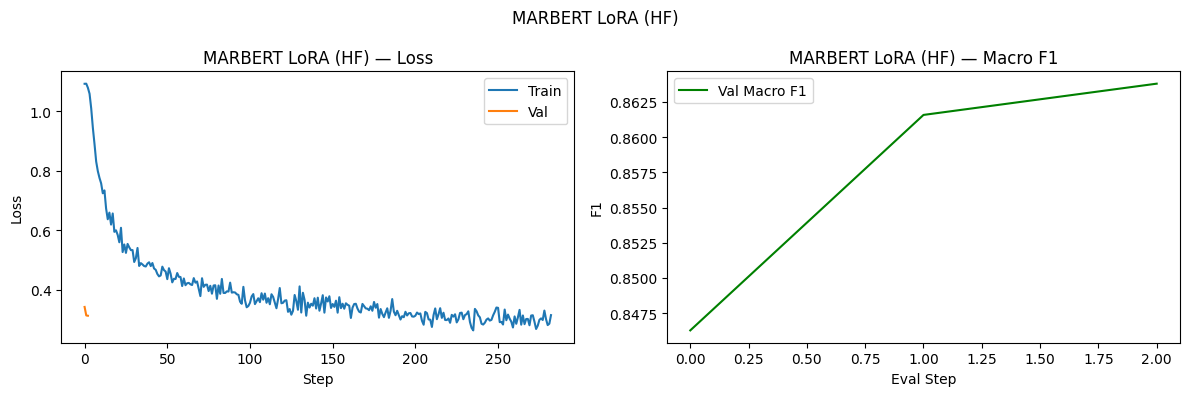


MARBERT LoRA (HF) — Test Macro F1: 0.8560  |  Accuracy: 0.8717

MARBERT LoRA (HF) — Classification Report
              precision    recall  f1-score   support

    Negative       0.81      0.85      0.83      5923
     Neutral       0.95      0.87      0.91     18036
    Positive       0.77      0.90      0.83      8381

    accuracy                           0.87     32340
   macro avg       0.85      0.87      0.86     32340
weighted avg       0.88      0.87      0.87     32340



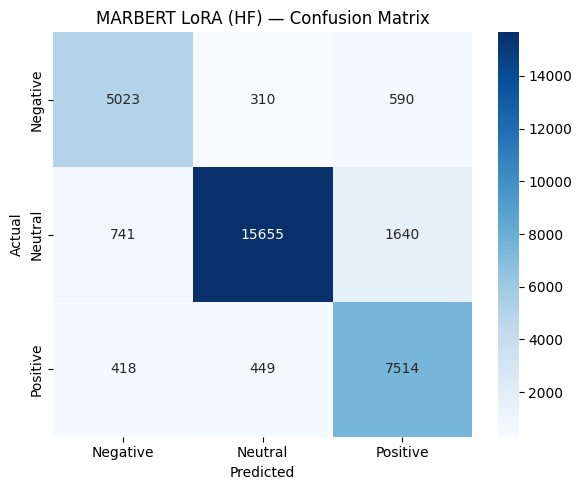

In [15]:
#plot training curves
plot_trainer_history(trainer_lora, "MARBERT LoRA (HF)", "results/huggingface/marbert_lora_curves.png")
f1_lora, acc_lora, preds_lora, _ = full_evaluation(trainer_lora, test_ds, "MARBERT LoRA (HF)", "results/huggingface/marbert_lora_cm.png")

**Cross-Framework Comparison**

In [20]:
#save HuggingFace results
hf_results = pd.DataFrame({
    "model" : ["MARBERT", "MARBERT"],
    "strategy" : ["Full FT", "LoRA"],
    "framework" : ["HF Trainer", "HF Trainer"],
    "test_macro_f1" : [round(f1_fft, 4), round(f1_lora,  4)],
    "test_accuracy" : [round(acc_fft, 4), round(acc_lora, 4)],
})
hf_results.to_csv("results/huggingface/hf_comparison.csv", index=False)
print("HuggingFace results:")
print(hf_results.to_string(index=False))

#load PyTorch results from pytorch_training_pipeline
pytorch_csv = Path("results/pytorch/pytorch_comparison.csv")
if pytorch_csv.exists():
    pt_results = pd.read_csv(pytorch_csv)
    print(f"\nPyTorch results loaded from {pytorch_csv}:")
    print(pt_results.to_string(index=False))
else:
    print(f"\nWarning: {pytorch_csv} not found. Run Notebook 01 first then re-run this cell.")
    pt_results = None

HuggingFace results:
  model strategy  framework  test_macro_f1  test_accuracy
MARBERT  Full FT HF Trainer         0.8828         0.8998
MARBERT     LoRA HF Trainer         0.8560         0.8717

PyTorch results loaded from results/pytorch/pytorch_comparison.csv:
       model pipeline  test_macro_f1  test_accuracy  trainable_params  best_val_f1
 MARBERT FFT  PyTorch         0.8837         0.9005         162843651       0.8923
MARBERT LoRA  PyTorch         0.8547         0.8719            297219       0.8653


Cross-framework comparison:
  model strategy  framework  test_macro_f1  test_accuracy
MARBERT  Full FT    PyTorch         0.8837         0.9005
MARBERT     LoRA    PyTorch         0.8547         0.8719
MARBERT  Full FT HF Trainer         0.8828         0.8998
MARBERT     LoRA HF Trainer         0.8560         0.8717


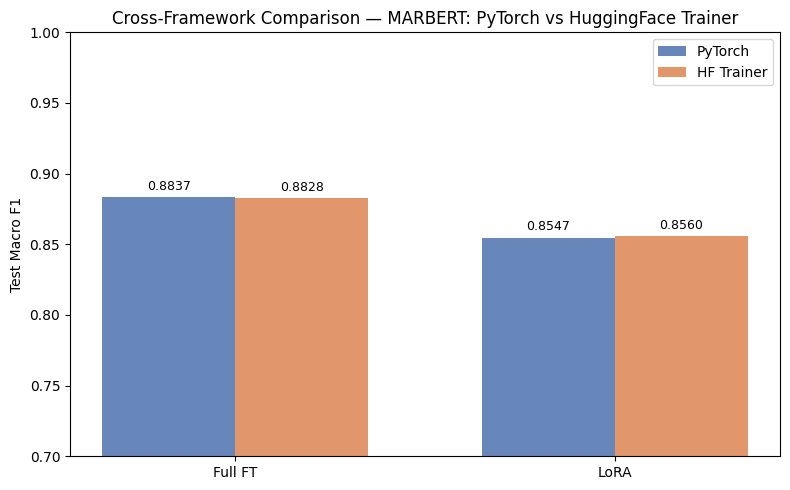


Saved: results/cross_framework_comparison.csv and results/cross_framework_chart.png


In [23]:
if pt_results is not None:
    pt_results_cleaned = pt_results.copy()
    pt_results_cleaned["framework"] = pt_results_cleaned["pipeline"]
    pt_results_cleaned["strategy"] = pt_results_cleaned["model"].apply(lambda x: x.split(" ")[1])
    pt_results_cleaned["strategy"] = pt_results_cleaned["strategy"].replace("FFT", "Full FT")
    pt_results_cleaned["model"] = pt_results_cleaned["model"].apply(lambda x: x.split(" ")[0])

    cross = pd.concat([
        pt_results_cleaned[["model", "strategy", "framework", "test_macro_f1", "test_accuracy"]], #combine both strategy metrics into one comparison table
        hf_results[["model", "strategy", "framework", "test_macro_f1", "test_accuracy"]],
    ], ignore_index=True)
    cross.to_csv("results/cross_framework_comparison.csv", index=False)
    print("Cross-framework comparison:")
    print(cross.to_string(index=False))

    #grouped bar chart
    labels_x = cross[cross["framework"] == "PyTorch"]["strategy"].tolist()
    pt_f1 = cross[cross["framework"] == "PyTorch"]["test_macro_f1"].tolist()
    hf_f1 = cross[cross["framework"] == "HF Trainer"]["test_macro_f1"].tolist()

    x = np.arange(len(labels_x))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - width/2, pt_f1, width, label="PyTorch", color="#4C72B0", alpha=0.85)
    bars2 = ax.bar(x + width/2, hf_f1, width, label="HF Trainer", color="#DD8452", alpha=0.85)
    ax.bar_label(bars1, fmt="%.4f", padding=3, fontsize=9)
    ax.bar_label(bars2, fmt="%.4f", padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_x)
    ax.set_ylim(0.7, 1.0)
    ax.set_ylabel("Test Macro F1")
    ax.set_title("Cross-Framework Comparison — MARBERT: PyTorch vs HuggingFace Trainer")
    ax.legend()
    plt.tight_layout()
    plt.savefig("results/cross_framework_chart.png", dpi=150)
    plt.show()
    plt.close()
    print("\nSaved: results/cross_framework_comparison.csv and results/cross_framework_chart.png")
else:
    print("Pytorch pipeline results do not exist.")

**Save to GitHub**

In [24]:
#push all results to github
os.system("git add results/ -f")
os.system('git commit -m "Add HuggingFace training results and cross-framework comparison"')
os.system("git push origin main")
print("Pushed Results to GitHub.")

Pushed Results to GitHub.


**Save models to Google Drive**

In [ ]:
#Save HuggingFace Trainer checkpoints to Google Drive
from google.colab import drive
import shutil, glob, os

drive.mount("/content/drive")
save_dir = "/content/drive/MyDrive/sentimentgulf_checkpoints"
os.makedirs(save_dir, exist_ok=True)
print("Saving HuggingFace Trainer checkpoints to Drive...")

#Full FT Checkpoints
trainer_fft.save_model(f"{save_dir}/hf_marbert_fft")
tokenizer.save_pretrained(f"{save_dir}/hf_marbert_fft")
print(f"Saved: hf_marbert_fft")

#LoRA Checkpoints
trainer_lora.save_model(f"{save_dir}/hf_marbert_lora")
tokenizer.save_pretrained(f"{save_dir}/hf_marbert_lora")
print(f"Saved: hf_marbert_lora")

print(f"\nAll checkpoints saved to: {save_dir}")
print("Note: hf_marbert_fft is a full model checkpoint (~600MB).")
print("hf_marbert_lora contains only the LoRA adapter weights (much smaller).")